Develop a program to demonstrate the working of Linear Regression and Polynomial Regression. Use Boston Housing dataset for linear regression and Auto MPG dataset for polynomial regression.

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [52]:
def show_results(X, y_true, y_pred, title, x_label, y_label, line=False):
    plt.scatter(X, y_true, label="Actual")

    (plt.plot if line else plt.scatter)(X, y_pred, c="r", label="Predicted")

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend()
    plt.show()

    print("MSE:", mean_squared_error(y_true, y_pred))
    print("R² :", r2_score(y_true, y_pred))

In [53]:
X, y = fetch_california_housing(as_frame=True, return_X_y=True)
Xtr, Xte, ytr, yte = train_test_split(X[["AveRooms"]], y, test_size=0.2, random_state=42)

lr = LinearRegression().fit(Xtr, ytr)
pred = lr.predict(Xte)

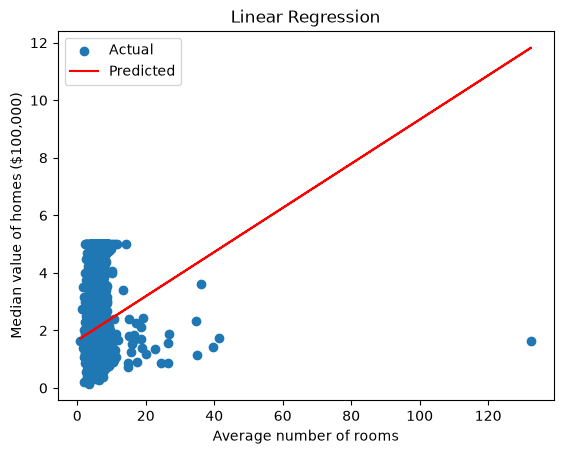

MSE: 1.2923314440807299
R² : 0.013795337532284901


In [54]:
show_results(Xte, yte, pred, "Linear Regression", "Average number of rooms", "Median value of homes ($100,000)", True)

In [55]:
autompg = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data",
    sep=r"\s+",
    names=["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year", "origin"],
    na_values="?"
).dropna()

X, y = autompg[["displacement"]], autompg["mpg"]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

pr = make_pipeline(PolynomialFeatures(2), StandardScaler(), LinearRegression()).fit(Xtr, ytr)
pred = pr.predict(Xte)

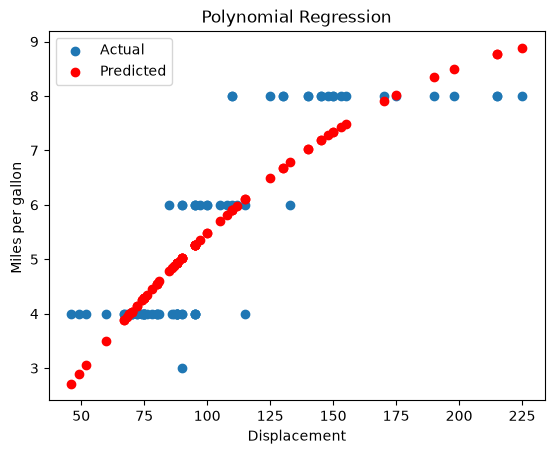

MSE: 0.7431490557205861
R² : 0.7505650609469626


In [56]:
show_results(Xte, yte, pred, "Polynomial Regression", "Displacement", "Miles per gallon ")